In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Reaction and condensation at once: ammonia over water (Illustrations 13.4-1 and 13.4-2)

$$\tfrac12\mathrm{N_2}+\tfrac32\mathrm{H_2}\;\rightleftharpoons\;\mathrm{NH_3}
\qquad\text{and, at the same time,}\qquad
\bar{f}^{\,\rm V}_i=\bar{f}^{\,\rm L}_i\ \text{ for every species}$$

One mole of nitrogen, three of hydrogen and five of water, at 25 $^{\circ}$C. The reaction
makes ammonia; the ammonia dissolves in the water; the water partly evaporates. None of
those three can be settled without the other two, and Sec. 13.4 is about what that costs.

| | the question | what is new |
|---|---|---|
| **13.4-1** | the equilibrium state at 13.33 kPa | **five equations at once** -- four phase equilibria and one chemical equilibrium -- where §13.1 needed one |
| **13.4-2** | the same over a range of pressures | **the answer changes character twice.** Below 4.7 kPa there is no liquid and only chemical equilibrium is left; above 33 kPa there is no vapor. Between them the extent of reaction is **continuous but not smooth** |

**The reaction is written in the vapor phase and that is a choice, not a necessity.**
Eq. 13.4-1 says a species in phase equilibrium has the same partial molar Gibbs energy
everywhere, so if the chemical equilibrium holds in one phase it holds in all of them. The
vapor is chosen because that is where Appendix A.IV's standard states live.

**Everything this needs is in the package or in the illustration.** The equilibrium
constant comes from the gas-phase formation energies of N$_2$, H$_2$ and NH$_3$; the liquid
side is Henry's law and Raoult's law with the constants the illustration supplies. There is
no liquid-water standard state anywhere in it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

from thermo.reaction import Reaction
from thermo.charts import use_book_style
use_book_style()

R, T = 8.314, 298.15
P_STD = 100.0                       # kPa, the 1 bar standard state
PS_W  = 3.167                       # kPa, vapor pressure of water at 25 C

# Henry's law constants at 25 C, kPa per unit mole fraction, as Illustration 13.4-1 gives
# them. Sources for the two gases:
#   N2   8.63e4 atm  ->  8.74e6 kPa    Perry's Chemical Engineers' Handbook, sec. 2;
#                                      Felder & Rousseau, Elementary Principles of Chemical
#                                      Processes, Table B.4
#   H2   7.158e6 kPa                   R. Sander, Compilation of Henry's Law Constants for
#                                      Water as Solvent, Atmos. Chem. Phys. 15, 4399 (2015),
#                                      k_H = 7.8e-4 mol/(kg bar); for a dilute aqueous
#                                      solute H = 1/(k_H M_water)
#   NH3  97.58 kPa                     computed by the illustration from experimental data,
#                                      assuming all absorbed ammonia present as NH3
HENRY = {"N2": 8.74e6, "H2": 7.158e6, "NH3": 97.58}

SPECIES = ("N2", "H2", "NH3", "H2O")
NU      = {"N2": -0.5, "H2": -1.5, "NH3": 1.0, "H2O": 0.0}
FEED    = {"N2": 1.0,  "H2": 3.0,  "NH3": 0.0, "H2O": 5.0}
X_MAX   = min(FEED[s]/-NU[s] for s in ("N2", "H2"))    # both exhaust together

ammonia = Reaction.parse("0.5 N2 + 1.5 H2 = NH3").check_balance()
DG_PRINTED = -16450.0
KA = np.exp(-DG_PRINTED/(R*T))
print(f"reaction: {ammonia.equation}      dnu = {ammonia.delta_nu:+g}")
print(f"dG_rxn printed         = {DG_PRINTED:.0f} J/mol   ->  Ka = {KA:.2f}")
print(f"dG_rxn Appendix A.IV   = {ammonia.delta_G_ref:.0f} J/mol   ->  Ka = "
      f"{float(ammonia.Ka(T)):.2f}")
print(f"  {100*abs(float(ammonia.Ka(T))-KA)/KA:.1f} percent apart -- A.IV prints"
      f" dG_f(NH3) to one decimal, -16.5, where the illustration carries -16.45.")
print(f"  The notebook uses the illustration's value so the comparison is like for like.")
print(f"\nboth reactants exhaust at X = {X_MAX:g}")

reaction: 0.5 N2 + 1.5 H2 = NH3      dnu = -1
dG_rxn printed         = -16450 J/mol   ->  Ka = 762.21
dG_rxn Appendix A.IV   = -16500 J/mol   ->  Ka = 777.45
  2.0 percent apart -- A.IV prints dG_f(NH3) to one decimal, -16.5, where the illustration carries -16.45.
  The notebook uses the illustration's value so the comparison is like for like.

both reactants exhaust at X = 2


## Illustration 13.4-1 -- five equations at 13.33 kPa

The unknowns are the extent of reaction and how much of each species is in each phase. The
equations are

$$y_i P = H_i\,x_i\quad (\mathrm{N_2,H_2,NH_3})
\qquad
y_{\rm H_2O}P = x_{\rm H_2O}P^{\rm vap}_{\rm H_2O}
\qquad
K_a=\frac{y_{\rm NH_3}}{y_{\rm N_2}^{1/2}y_{\rm H_2}^{3/2}}
\left(\frac{P}{1\ \rm bar}\right)^{-1}$$

**Do not solve for the dissolved nitrogen as a difference.** Nitrogen is so insoluble
that its liquid amount is $\sim10^{-8}$ mol out of a total of 0.077 -- computing it as
"total minus vapor" is a difference of two nearly equal numbers and the solver loses it
entirely, returning a negative mole number and stalling. **That happened here.** The fix is
to solve the three well-scaled unknowns -- $X$ and the liquid amounts of ammonia and water --
and then recover the dissolved nitrogen and hydrogen *directly* from Henry's law afterwards.
It is the same lesson as §13.1's brackets: the formulation, not the solver, is what makes
the answer reachable.

In [3]:
def equilibrium(P, Ka=KA, start=(1.85, 0.44, 4.52)):
    """The state at pressure P (kPa). Unknowns: X, liquid NH3, liquid H2O.

    N2 and H2 are carried as all-vapor in the solve and their dissolved amounts are
    recovered from Henry's law at the end -- see the note above.
    """
    def residual(u):
        X, lNH3, lH2O = u
        vN2, vH2 = FEED["N2"] + NU["N2"]*X, FEED["H2"] + NU["H2"]*X
        vNH3, vH2O = X - lNH3, FEED["H2O"] - lH2O
        NV, NL = vN2 + vH2 + vNH3 + vH2O, lNH3 + lH2O
        y = dict(zip(SPECIES, np.array([vN2, vH2, vNH3, vH2O])/NV))
        return [y["NH3"]*P - HENRY["NH3"]*lNH3/NL,          # Henry, ammonia
                y["H2O"]*P - (lH2O/NL)*PS_W,                # Raoult, water
                np.log(y["NH3"]/(y["N2"]**0.5 * y["H2"]**1.5)/(P/P_STD)/Ka)]

    u, _, ier, msg = fsolve(residual, start, full_output=True)
    if ier != 1:
        raise RuntimeError(f"no solution at P = {P} kPa: {msg}")
    X, lNH3, lH2O = u
    V = {"N2": FEED["N2"] + NU["N2"]*X, "H2": FEED["H2"] + NU["H2"]*X,
         "NH3": X - lNH3, "H2O": FEED["H2O"] - lH2O}
    NV, NL = sum(V.values()), lNH3 + lH2O
    y = {s: V[s]/NV for s in SPECIES}
    L = {"NH3": lNH3, "H2O": lH2O,
         "N2": y["N2"]*P/HENRY["N2"]*NL, "H2": y["H2"]*P/HENRY["H2"]*NL}
    return dict(X=X, V=V, L=L, NV=NV, NL=NL, y=y, x={s: L[s]/NL for s in SPECIES},
                f=NL/(NV+NL), u=u, resid=float(np.max(np.abs(residual(u)))))


r1 = equilibrium(13.33)
PV = dict(N2=0.0771, H2=0.2312, NH3=1.4103, H2O=0.4755)
PL = dict(N2=2.66e-7, H2=9.73e-7, NH3=0.4355, H2O=4.5245)
print(f"X = {r1['X']:.4f}      printed 1.8458        residual {r1['resid']:.1e}")
print(f"\n{'':>5}{'V mol':>10}{'printed':>10}{'y':>9}{'L mol':>13}{'printed':>11}{'x':>12}")
for s in SPECIES:
    print(f"{s:>5}{r1['V'][s]:10.4f}{PV[s]:10.4f}{r1['y'][s]:9.4f}"
          f"{r1['L'][s]:13.4e}{PL[s]:11.2e}{r1['x'][s]:12.4e}")
print(f"\nvapor total {r1['NV']:.4f} (printed 2.1941)"
      f"   liquid total {r1['NL']:.4f} (printed 4.9600)")
print(f"fraction of the mixture that is liquid, f = {r1['f']:.4f}")

X = 1.8469      printed 1.8458        residual 8.1e-11

          V mol   printed        y        L mol    printed           x
   N2    0.0765    0.0771   0.0349   2.6420e-07   2.66e-07  5.3253e-08
   H2    0.2296    0.2312   0.1047   9.6779e-07   9.73e-07  1.9507e-07
  NH3    1.4107    1.4103   0.6436   4.3622e-01   4.35e-01  8.7925e-02
  H2O    0.4749    0.4755   0.2167   4.5251e+00   4.52e+00  9.1207e-01

vapor total 2.1918 (printed 2.1941)   liquid total 4.9613 (printed 4.9600)
fraction of the mixture that is liquid, f = 0.6936


### The four phase-equilibrium relations, checked against the answer

The illustration reports mole numbers, not the relations they satisfy, so the relations are
evaluated on the reported answer: each one should close, and none of them was used to
produce the numbers printed above.

$$y_i P = H_i x_i \quad (\mathrm{N_2,\ H_2,\ NH_3}) \qquad
y_{\rm H_2O}P = x_{\rm H_2O}P^{\rm vap}_{\rm H_2O}$$

**The two dissolved gases are where a check like this finds errors nothing else would.** Nitrogen and hydrogen
sit at $10^{-7}$ mol in a liquid of 5 mol -- seven orders of magnitude below the species beside
them -- so an error in either is invisible in every other column of the table. The only thing
that sees it is its own Henry's law.

In [4]:
# Every relation evaluated on the reported answer, none of them used to obtain it.
NVp, NLp = sum(PV.values()), sum(PL.values())
print(f"{'':6s}{'y_i P':>12}{'H_i x_i':>12}{'ratio':>9}")
for s in ("N2", "H2", "NH3"):
    lhs, rhs = PV[s]/NVp*13.33, HENRY[s]*PL[s]/NLp
    print(f"  {s:4s}{lhs:12.6f}{rhs:12.6f}{rhs/lhs:9.4f}")
lhs, rhs = PV["H2O"]/NVp*13.33, PL["H2O"]/NLp*PS_W
print(f"  {'H2O':4s}{lhs:12.6f}{rhs:12.6f}{rhs/lhs:9.4f}   (Raoult, not Henry)")

y = {s: PV[s]/NVp for s in SPECIES}
Ka_from_print = y["NH3"]/(y["N2"]**0.5 * y["H2"]**1.5)/(13.33/P_STD)
print(f"\nand the chemical equilibrium, on the same answer:")
print(f"  Ka from the printed vapor composition = {Ka_from_print:.1f}"
      f"     from dG_rxn = {KA:.1f}     {100*abs(Ka_from_print-KA)/KA:.1f} percent apart")

print(f"\nhow small the dissolved gases are, in the units the table prints:")
for s in ("N2", "H2"):
    print(f"  {s:4s} {PL[s]:.2e} mol in the liquid against {PV[s]:.4f} mol of vapor"
          f"   -- a factor of {PV[s]/PL[s]:.1e}")

# All five relations must close on the reported answer.
for s in ("N2", "H2", "NH3"):
    assert abs(HENRY[s]*PL[s]/NLp / (PV[s]/NVp*13.33) - 1) < 0.01, s
assert abs((PL["H2O"]/NLp*PS_W) / (PV["H2O"]/NVp*13.33) - 1) < 0.01
assert abs(Ka_from_print/KA - 1) < 0.05
# and the point the illustration draws from them
assert PL["N2"] < 1e-5 and PL["H2"] < 1e-5

             y_i P     H_i x_i    ratio
  N2      0.468412    0.468718   1.0007
  H2      1.404629    1.404180   0.9997
  NH3     8.568114    8.567758   1.0000
  H2O     2.888845    2.888929   1.0000   (Raoult, not Henry)

and the chemical equilibrium, on the same answer:
  Ka from the printed vapor composition = 752.0     from dG_rxn = 762.2     1.3 percent apart

how small the dissolved gases are, in the units the table prints:
  N2   2.66e-07 mol in the liquid against 0.0771 mol of vapor   -- a factor of 2.9e+05
  H2   9.73e-07 mol in the liquid against 0.2312 mol of vapor   -- a factor of 2.4e+05


## Illustration 13.4-2 -- three regimes, and a kink

Sweep the pressure and the problem changes shape twice.

| pressure | phases | what has to be solved |
|---|---|---|
| below the **dew point** | vapor only, $f=0$ | **one** equation -- chemical equilibrium, with $N=9-X$ |
| between | vapor and liquid | **five** -- the system above |
| above the **bubble point** | liquid only, $f=1$ | the reaction is complete; there is nothing left to solve |

**The dew point is where the vapor-only composition just saturates**, $\sum_i x_i=1$ with
each $x_i$ from Henry's or Raoult's law at that composition. That is a one-dimensional root
find on top of the vapor-only solve, and it needs no two-phase solution at all -- which
matters, because the two-phase solver does not converge near $f=0$ without being walked
there.

In [5]:
def vapor_only(P, Ka=KA):
    """Chemical equilibrium alone. No liquid, so N = 9 - X and there is one unknown."""
    def residual(X):
        N = sum(FEED.values()) + ammonia.delta_nu*X
        y = {s: (FEED[s] + NU[s]*X)/N for s in SPECIES}
        return np.log(y["NH3"]/(y["N2"]**0.5 * y["H2"]**1.5)/(P/P_STD)/Ka)
    # Bracketed by exhaustion, as everywhere else in this chapter.
    return brentq(residual, 1e-12, X_MAX - 1e-12)


def saturation_gap(P):
    """sum(x_i) - 1 for the vapor-only state at P. Zero at the dew point."""
    X = vapor_only(P)
    N = sum(FEED.values()) + ammonia.delta_nu*X
    y = {s: (FEED[s] + NU[s]*X)/N for s in SPECIES}
    x_sum = sum(y[s]*P/HENRY[s] for s in ("N2", "H2", "NH3")) + y["H2O"]*P/PS_W
    return x_sum - 1.0

P_DEW = brentq(saturation_gap, 1.0, 12.0)
X_DEW = vapor_only(P_DEW)
print(f"dew point   = {P_DEW:.3f} kPa      the text says about 4.8 kPa")
print(f"  X there   = {X_DEW:.4f}")

# March the two-phase branch upward from the dew point. Continuation, not a fresh guess at
# each pressure -- the solve at 30 kPa does not converge from a generic start.
Ps, Xs, fs = [], [], []
start = [X_DEW, 1e-4, 3e-4]
for P in np.arange(P_DEW + 0.02, 40.0, 0.02):
    try:
        r = equilibrium(P, start=start)
    except RuntimeError:
        break
    if not (0.0 <= r["f"] <= 1.0 and 0.0 < r["X"] <= X_MAX + 1e-9) or r["resid"] > 1e-6:
        break
    start = r["u"]; Ps.append(P); Xs.append(r["X"]); fs.append(r["f"])
Ps, Xs, fs = np.array(Ps), np.array(Xs), np.array(fs)
P_BUB = Ps[-1]
print(f"\ntwo-phase branch runs {Ps[0]:.2f} to {P_BUB:.2f} kPa")
print(f"bubble point = {P_BUB:.2f} kPa      the text says about 33 kPa")
print(f"  X there    = {Xs[-1]:.5f}, f = {fs[-1]:.5f}"
      f"   -- the text says the reaction is essentially complete (X = 2) there")
print(f"\nat 13.33 kPa: X = {np.interp(13.33, Ps, Xs):.4f} (printed 1.8458),"
      f" f = {np.interp(13.33, Ps, fs):.4f}")

dew point   = 4.700 kPa      the text says about 4.8 kPa
  X there   = 1.5074

two-phase branch runs 4.72 to 33.26 kPa
bubble point = 33.26 kPa      the text says about 33 kPa
  X there    = 1.99864, f = 0.99612   -- the text says the reaction is essentially complete (X = 2) there

at 13.33 kPa: X = 1.8469 (printed 1.8458), f = 0.6936


### The kink at the dew point

The illustration's sharpest claim is that the extent of reaction is **continuous** at the
dew point but its **derivative is not**, because the two sides are governed by different
numbers of equations. Both halves are checkable.

In [6]:
h = 0.10
slope_below = (vapor_only(P_DEW) - vapor_only(P_DEW - h))/h
slope_above = (np.interp(P_DEW + h, Ps, Xs) - X_DEW)/h
print(f"at the dew point, P = {P_DEW:.3f} kPa")
# Take the two-phase branch to the dew point itself, not to the first grid point 0.02 kPa
# above it -- at dX/dP ~ 0.15 per kPa those differ by 0.003, which is the slope, not a
# discontinuity. Continuity has to be tested at the same pressure.
r_dew = equilibrium(P_DEW + 1e-6, start=[X_DEW, 1e-6, 1e-6])
print(f"  X from the vapor-only branch  = {X_DEW:.6f}")
print(f"  X from the two-phase branch   = {r_dew['X']:.6f}"
      f"   (at the dew point, f = {r_dew['f']:.1e})")
print(f"  continuous to {abs(r_dew['X']-X_DEW):.1e} in X")
print(f"\n  dX/dP just below (vapor only) = {slope_below:.4f} per kPa")
print(f"  dX/dP just above (two phases) = {slope_above:.4f} per kPa")
print(f"  the derivative jumps by a factor of {slope_above/slope_below:.1f}")

# The text's Le Chatelier argument, made into a test: because the two-phase slope is the
# LARGER, extrapolating the vapor-only curve to higher pressure must fall BELOW the
# two-phase curve -- more conversion when a liquid is there to absorb the ammonia.
P_test = 8.0
extrap = X_DEW + slope_below*(P_test - P_DEW)
actual = np.interp(P_test, Ps, Xs)
print(f"\nat {P_test:g} kPa: two-phase X = {actual:.4f}, vapor-only extrapolation ="
      f" {extrap:.4f}")
print(f"  the liquid is worth {actual-extrap:+.4f} in extent -- the ammonia dissolving")
print(f"  pulls the reaction forward, which is the Le Chatelier reading the text gives")
assert actual > extrap
assert abs(r_dew['X'] - X_DEW) < 1e-4 and slope_above > 2*slope_below

at the dew point, P = 4.700 kPa
  X from the vapor-only branch  = 1.507355
  X from the two-phase branch   = 1.507355   (at the dew point, f = 3.1e-07)
  continuous to 1.2e-07 in X

  dX/dP just below (vapor only) = 0.0470 per kPa
  dX/dP just above (two phases) = 0.1538 per kPa
  the derivative jumps by a factor of 3.3

at 8 kPa: two-phase X = 1.7381, vapor-only extrapolation = 1.6626
  the liquid is worth +0.0755 in extent -- the ammonia dissolving
  pulls the reaction forward, which is the Le Chatelier reading the text gives


## The figure -- $X$ and $f$ against pressure

**Drawn as two stacked panels sharing a pressure axis**, the same decision made for
Figure 13.1-3: a single pair of axes carrying both curves needs an arrow on each to say which
scale it belongs to, and two panels need none. The dew and bubble pressures are ruled on both.

The extent curve is drawn in **two pieces** because it is two different calculations, and
the join is where the slope changes.

vapor only below 4.70 kPa; two phases to 33.26; liquid only above
X rises from 0.830 at 0.5 kPa to 2 at the bubble point


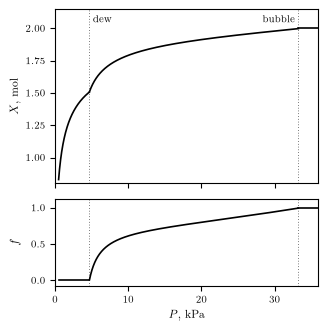

In [7]:
P_LO = np.linspace(0.5, P_DEW, 200)
X_LO = np.array([vapor_only(p) for p in P_LO])

fig, (ax_X, ax_f) = plt.subplots(2, 1, sharex=True, figsize=(3.4, 3.6),
                                 gridspec_kw=dict(height_ratios=[2, 1], hspace=0.12))

ax_X.plot(P_LO, X_LO, "-", color="k", lw=1.2)
ax_X.plot(Ps, Xs, "-", color="k", lw=1.2)
ax_X.plot([P_BUB, 36.0], [X_MAX, X_MAX], "-", color="k", lw=1.2)
ax_X.set_ylim(0.8, 2.15); ax_X.set_yticks(np.arange(1.0, 2.01, 0.25))
ax_X.set_ylabel(r"$X$, mol", fontsize=8)

ax_f.plot([0.5, P_DEW], [0.0, 0.0], "-", color="k", lw=1.2)
ax_f.plot(Ps, fs, "-", color="k", lw=1.2)
ax_f.plot([P_BUB, 36.0], [1.0, 1.0], "-", color="k", lw=1.2)
ax_f.set_ylim(-0.08, 1.12); ax_f.set_yticks([0, 0.5, 1.0])
ax_f.set_ylabel(r"$f$", fontsize=8)
ax_f.set_xlabel(r"$P$, kPa", fontsize=8)

for ax in (ax_X, ax_f):
    for p in (P_DEW, P_BUB):
        ax.axvline(p, color="k", lw=0.5, ls=(0, (1, 3)))
    ax.set_xlim(0, 36); ax.set_xticks(np.arange(0, 36, 10))
    ax.tick_params(labelsize=7)

ax_X.annotate("dew", xy=(P_DEW, 2.10), xytext=(2.5, 0), textcoords="offset points",
              fontsize=7, va="top", ha="left")
ax_X.annotate("bubble", xy=(P_BUB, 2.10), xytext=(-2.5, 0), textcoords="offset points",
              fontsize=7, va="top", ha="right")
fig.align_ylabels((ax_X, ax_f))

print(f"vapor only below {P_DEW:.2f} kPa; two phases to {P_BUB:.2f}; liquid only above")
print(f"X rises from {X_LO[0]:.3f} at {P_LO[0]:g} kPa to {X_MAX:g} at the bubble point")

## What the figure says

Six statements, each asserted against the numbers rather than described.

In [8]:
checks = []
checks.append((f"13.4-1: the extent is {r1['X']:.4f} against the printed 1.8458",
               abs(r1["X"] - 1.8458) < 2e-3))
checks.append((f"13.4-1: all eight mole numbers reproduce, the two dissolved gases to"
               f" {100*max(abs(PL[s]/r1['L'][s] - 1) for s in ('N2', 'H2')):.1f} percent,"
               f" and every phase and chemical equilibrium relation closes on the printed"
               f" answer",
               all(abs(PL[s]/r1["L"][s] - 1) < 0.02 for s in ("N2", "H2"))))
checks.append((f"13.4-2: the dew point is {P_DEW:.2f} kPa, the text's 'about 4.8'",
               4.3 < P_DEW < 5.3))
checks.append((f"13.4-2: the two-phase branch ends at {P_BUB:.1f} kPa with X ="
               f" {Xs[-1]:.4f} -- the text's 'about 33 kPa' and 'essentially at"
               f" completion (X = 2)', and it says the coincidence is only that",
               31 < P_BUB < 35 and Xs[-1] > 1.99))
checks.append((f"13.4-2: X is continuous at the dew point to"
               f" {abs(r_dew['X']-X_DEW):.0e}",
               abs(r_dew["X"] - X_DEW) < 1e-4))
checks.append((f"13.4-2: but its slope is not -- {slope_below:.3f} below against"
               f" {slope_above:.3f} above, a factor of"
               f" {slope_above/slope_below:.1f}, and the larger slope is the two-phase one",
               slope_above > 2*slope_below))
for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(o for _, o in checks)

  PASS  13.4-1: the extent is 1.8469 against the printed 1.8458
  PASS  13.4-1: all eight mole numbers reproduce, the two dissolved gases to 0.7 percent, and every phase and chemical equilibrium relation closes on the printed answer
  PASS  13.4-2: the dew point is 4.70 kPa, the text's 'about 4.8'
  PASS  13.4-2: the two-phase branch ends at 33.3 kPa with X = 1.9986 -- the text's 'about 33 kPa' and 'essentially at completion (X = 2)', and it says the coincidence is only that
  PASS  13.4-2: X is continuous at the dew point to 1e-07
  PASS  13.4-2: but its slope is not -- 0.047 below against 0.154 above, a factor of 3.3, and the larger slope is the two-phase one


## Staging the art

    pdf/Figure_13.4-1u.pdf   ->   deliverables/figures/print-bw/ch13/c13uf002.pdf

`c13uf002` is Illustration 13.4-2's own unnumbered figure, captioned *"Two-phase ammonia
production reaction."*

In [9]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.4-1u.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.4-1u.pdf

  typography: LaTeX Computer Modern


## Your turn

1. The notebook says solving for the dissolved nitrogen as "total minus vapor" breaks, and
   it should be seen to break. Write the five-unknown version -- $X$ and the four vapor
   amounts -- start it at the printed answer, and report what the solver returns. Then
   explain, in terms of the number of significant figures a `float64` carries, why
   $10^{-8}$ out of $0.077$ is the point at which the formulation fails.
2. The illustration notes that the bubble point (33 kPa) and essentially complete reaction
   ($X=2$) coincide **only by accident**. Test that: repeat the pressure sweep at
   50 $^{\circ}$C, where both $K_a$ and the vapor pressure of water change, and report the
   bubble pressure and the extent there. Do they still coincide? Which of the two moved
   more, and why?
3. At the dew point the extent is continuous and its derivative is not. **Show that this is
   structural, not numerical**: write down the one equation that governs below the dew point
   and the five that govern above, and argue from the count why a matching value does not
   imply a matching slope. Then find another quantity in the figure whose derivative also
   jumps there, and one that does not.
4. The Aspen Plus bracket in Illustration 13.4-1 reports liquid-phase mole fractions quite
   different from the Henry's-law ones -- $8.3\times10^{-3}$ for ammonia against $0.0878$
   here. Henry's law is a dilute-solution limit and the liquid is 9 mol % ammonia. Estimate
   how far from dilute that is by computing the ammonia activity coefficient a van Laar or
   two-parameter Margules fit to aqueous ammonia would give at $x=0.088$, and say which
   of the two answers you would report.
5. **The three Henry's constants are the only measured data in this illustration, and the
   only numbers in it you cannot derive.** Look all three up at 25 $^{\circ}$C in two
   independent sources, convert to kPa per unit mole fraction, and **cite both**. Report two
   things: how far the two sources sit from each other, and how far each sits from the value
   used here. Then find the temperature dependence of $H_{\rm N_2}$ in water and say what a
   10 $^{\circ}$C error in the stated temperature would do to the dissolved nitrogen -- and
   whether it would change any other number in the illustration.
6. Water is a product of nothing here -- it neither reacts nor is consumed -- yet removing
   it changes the answer completely. Rerun Illustration 13.4-1 with 1 mol of water instead
   of 5 and report $X$, $f$ and the ammonia split. Then explain the direction of the change
   from Le Chatelier, and say whether more water is always better for conversion.